In [2]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import os
from statsmodels.stats.anova import AnovaRM
import pingouin as pg
from scipy.stats import ttest_1samp, pearsonr, ttest_rel
from SensoriMotorPrediction.vis import plot_binned_cue, plot_binned_finger_cue, plot_aligned_deviation, plot_aligned_force
from SensoriMotorPrediction.util import anova_finger_cue

import SensoriMotorPrediction.globals as gl

plt.style.use('default')

Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: data/atlases


# Demographics
## Experiment 1

In [3]:
experiment = 'smp2'
participants = pd.read_csv(os.path.join('data', 'participants.tsv'), sep='\t')
participants_exp1 = participants[participants['Experiment'] == 1]
participants_exp2 = participants[participants['Experiment'] == 2]

demographics = {
    'Total Participants': len(participants_exp1),
    'Gender Distribution': participants_exp1['sex'].value_counts(),
    'Average Age': participants_exp1['age'].mean(),
    'SD Age': participants_exp1['age'].std(),
    'Age Range': (participants_exp1['age'].min(), participants_exp1['age'].max()),
    'Handedness Distribution': participants_exp1['handedness'].value_counts(),
}

# Print the summary
for key, value in demographics.items():
    print(f"{key}: {value}")

Total Participants: 14
Gender Distribution: sex
m    8
f    6
Name: count, dtype: int64
Average Age: 21.357142857142858
SD Age: 4.162232072359232
Age Range: (np.int64(18), np.int64(34))
Handedness Distribution: handedness
right    14
Name: count, dtype: int64


## Experiment 2

In [4]:
demographics = {
    'Total Participants': len(participants_exp2),
    'Gender Distribution': participants_exp2['sex'].value_counts(),
    'Average Age': participants_exp2['age'].mean(),
    'SD Age': participants_exp2['age'].std(),
    'Age Range': (participants_exp2['age'].min(), participants_exp2['age'].max()),
    'Handedness Distribution': participants_exp2['handedness'].value_counts(),
}

# Print the summary
for key, value in demographics.items():
    print(f"{key}: {value}")

Total Participants: 10
Gender Distribution: sex
M    8
F    2
Name: count, dtype: int64
Average Age: 25.7
SD Age: 3.7727090178455764
Age Range: (np.int64(21), np.int64(32))
Handedness Distribution: handedness
right    10
Name: count, dtype: int64


# Reaction time

In [5]:
filepath = os.path.join(gl.baseDir, experiment, gl.behavDir, f'behaviour.trial.tsv')
dat = pd.read_csv(filepath, sep='\t', )
dat_gonogo = dat.groupby(['sn', 'GoNogo']).mean(numeric_only=True).reset_index()
RT = dat_gonogo[dat_gonogo['GoNogo']=='go'].RT_global
print(f'RT={RT.mean()}+/-{RT.std()}')

RT=0.1737678856509274+/-0.020580620266387115


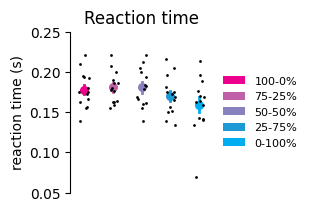

In [5]:
from matplotlib.patches import Patch

dat_cue = dat.groupby(['sn', 'cue', 'GoNogo', ]).mean(numeric_only=True).reset_index()
fig, ax = plt.subplots(figsize=(3, 2), constrained_layout=True)
plot_binned_cue(fig, ax, dat_cue[dat_cue.GoNogo=='go'], y='RT_global')
ax.set_ylim((.05, .25))
ax.spines[['left']].set_bounds(.05, .25)
ax.set_ylabel('reaction time (s)')
ax.set_title('Reaction time')
plt.show()

Perturbation,Source,F,DF,p-unc
index,cue,23.420505,3,0.000000
index,Error,nan,39,nan
ring,cue,2.225849,3,0.100460
ring,Error,nan,39,nan


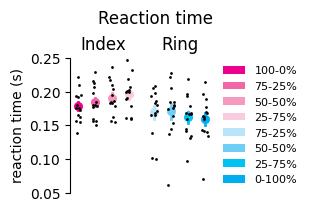

In [6]:
dat_finger_cue = dat.groupby(['sn', 'stimFinger', 'cue']).mean(numeric_only=True).reset_index()
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(3, 2), constrained_layout=True)
plot_binned_finger_cue(fig, axs, dat_finger_cue, y=['RT_global', 'RT_global'], finger=('index', 'ring'))
axs[0].set_ylim((.05, .25))
axs[0].spines[['left']].set_bounds(.05, .25)
axs[0].set_ylabel('reaction time (s)')
fig.suptitle('Reaction time')

anova_finger_cue(dat_finger_cue, dv=('RT_global', 'RT_global'), within='cue')

plt.show()

# Force response aligned to perturbation (Fig. 1b)

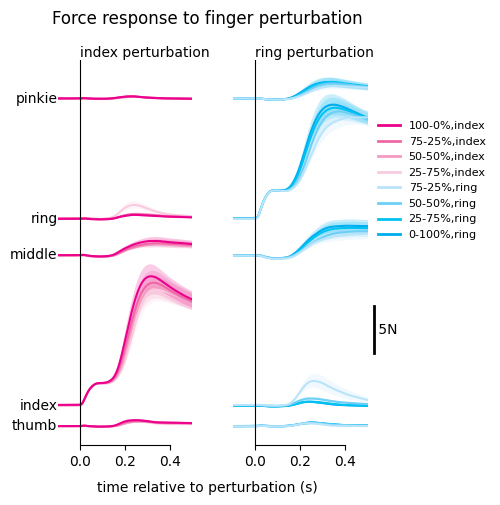

In [7]:
npz = np.load(os.path.join('data', gl.behavDir, 'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())
force = force[descr.GoNogo == 'go']
descr = descr[descr.GoNogo == 'go']
fig, axs = plt.subplots(1, 2, figsize=(4, 5), sharey=True, sharex=True)
plot_aligned_force(fig, axs, force.copy(), descr)
plt.show()

# Mean force response 0.2-0.4s from perturbation (Fig. 1c)

Perturbation,Source,F,DF,p-unc
index,cue,21.134531,3,0.000000
index,Error,nan,39,nan
ring,cue,6.109507,3,0.001647
ring,Error,nan,39,nan


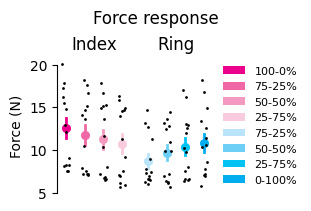

In [8]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(3, 2), constrained_layout=True)
plot_binned_finger_cue(fig, axs, dat_finger_cue, y=['index1', 'ring1'], finger=('index', 'ring'))
axs[0].spines[['left']].set_bounds(5, 20)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Force response')

anova_finger_cue(dat_finger_cue, dv=('index1', 'ring1'), within='cue')

plt.show()

# Force trajectories (Fig. 1d)

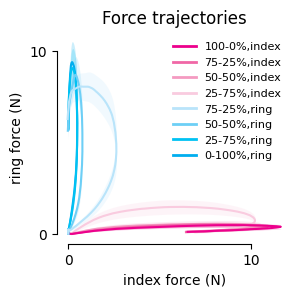

In [9]:
fig, ax = plt.subplots(figsize=(5, 2.75))
cut = .06 # skip first 60ms (no active force generated)
startSample = int(gl.prestim * gl.fsample_mov + cut * gl.fsample_mov)
force_cut = force[:, startSample:]
force_cut = force_cut - force_cut[:, 0][:, None]
plot_aligned_deviation(fig, ax, force_cut, descr)

plt.show()

# Mean deviation from straight force trajectory (Fig. 1e)

Mean deviation for perturbation on cued vs. uncued finger
Index perturbation: t=2.744, p=0.008
Ring perturbation: t=3.201, p=0.003


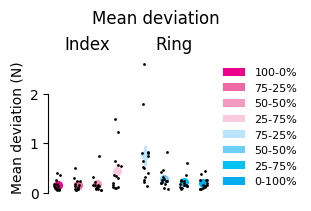

In [10]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(3, 2), constrained_layout=True)
plot_binned_finger_cue(fig, axs, dat_finger_cue, y=['MD', 'MD'], finger=('index', 'ring'))
axs[0].spines[['left']].set_bounds(0, 2)
axs[0].set_ylabel('Mean deviation (N)')

fig.suptitle('Mean deviation')

dat_stat = dat.groupby(['sn', 'stimFinger', 'Unexpected']).mean(numeric_only=True).reset_index()
dat_stat = dat_stat[dat_stat['Unexpected']>=0]

print('Mean deviation for perturbation on cued vs. uncued finger')
dat_stat_index = dat_stat[dat_stat['stimFinger']=='index']
x1 = dat_stat_index[dat_stat_index['Unexpected']==1].MD.to_numpy()
x0 = dat_stat_index[dat_stat_index['Unexpected']==0].MD.to_numpy()
tval, pval = ttest_1samp(x1 - x0, 0, alternative='greater')
print(f'Index perturbation: t={tval:.3f}, p={pval:.3f}')

dat_stat_index = dat_stat[dat_stat['stimFinger']=='ring']
x1 = dat_stat_index[dat_stat_index['Unexpected']==1].MD.to_numpy()
x0 = dat_stat_index[dat_stat_index['Unexpected']==0].MD.to_numpy()
tval, pval = ttest_1samp(x1 - x0, 0, alternative='greater')
print(f'Ring perturbation: t={tval:.3f}, p={pval:.3f}')

plt.show()